In [1]:
churn_training.ipynb
import pandas as pd

NameError: name 'churn_training' is not defined

In [2]:
import pandas as pd

In [3]:
import pandas as pd


In [4]:
df = pd.read_csv("../data/Bank Customer Churn Prediction.csv")

In [5]:
df.head()


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.shape

(10000, 12)

In [7]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='str')

In [8]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [11]:
df = df.drop("customer_id", axis=1)

In [12]:
df.columns

Index(['credit_score', 'country', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary',
       'churn'],
      dtype='str')

In [13]:
df.to_csv("../output/cleaned_data.csv", index=False)

In [14]:
df["churn"].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

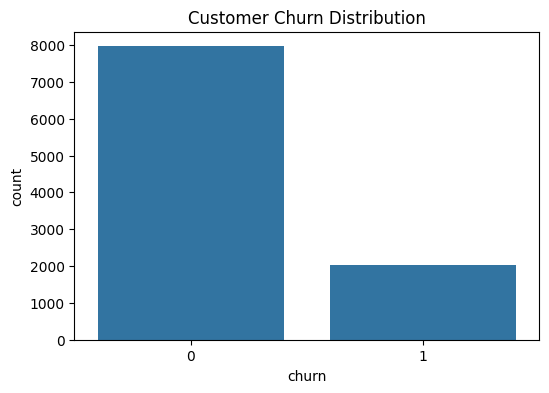

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="churn",
    data=df
)

plt.title("Customer Churn Distribution")

plt.savefig(
    "../output/plots/churn_distribution.png"
)

plt.show()

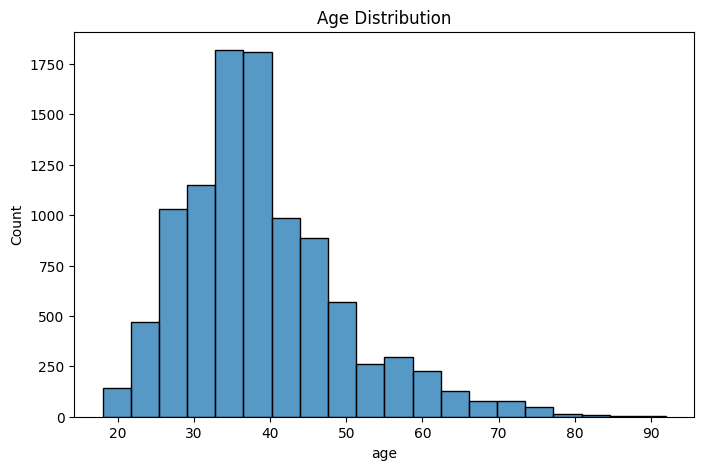

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=20
)

plt.title("Age Distribution")

plt.savefig(
    "../output/plots/age_distribution.png"
)

plt.show()

In [18]:
df.select_dtypes(include="object").columns

/var/folders/82/dnd8wp1n58v6fhnhlrc7gt9r0000gn/T/ipykernel_2037/1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['country', 'gender'], dtype='str')

In [19]:
df.select_dtypes(include=["object","string"]).columns

Index(['country', 'gender'], dtype='str')

In [20]:
from sklearn.preprocessing import LabelEncoder

In [21]:
encoder = LabelEncoder()

In [22]:
df["country"] = encoder.fit_transform(df["country"])

df["gender"] = encoder.fit_transform(df["gender"])

In [23]:
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [24]:
X = df.drop("churn", axis=1)

y = df["churn"]

In [25]:
X.shape, y.shape

((10000, 10), (10000,))

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
X_train.shape, X_test.shape

((8000, 10), (2000, 10))

In [29]:
from xgboost import XGBClassifier

In [30]:
model = XGBClassifier(
    random_state=42
)

In [31]:
model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [32]:
predictions = model.predict(X_test)

In [33]:
predictions[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [34]:
X_train.shape, X_test.shape
predictions[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [35]:
from sklearn.metrics import accuracy_score

In [36]:
accuracy = accuracy_score(
    y_test,
    predictions
)

accuracy

0.8555

In [37]:
from sklearn.metrics import classification_report

In [38]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1607
           1       0.68      0.49      0.57       393

    accuracy                           0.86      2000
   macro avg       0.78      0.72      0.74      2000
weighted avg       0.84      0.86      0.85      2000



In [39]:
metrics_df = pd.DataFrame({
    "metric":["accuracy"],
    "value":[accuracy]
})

In [40]:
metrics_df.to_csv(
    "../output/metrics.csv",
    index=False
)

In [41]:
importance = model.feature_importances_

In [42]:
feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

In [43]:
feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

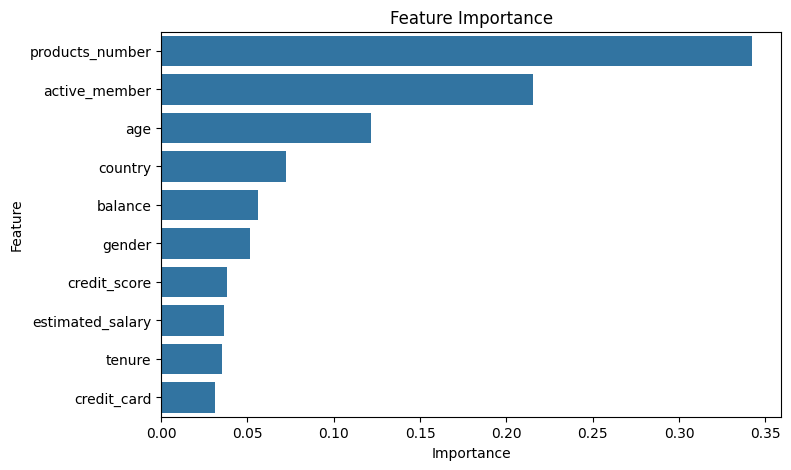

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_df
)

plt.title(
    "Feature Importance"
)

plt.savefig(
    "../output/feature_importance.png"
)

plt.show()

In [45]:
accuracy


0.8555

In [46]:
prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

prediction_df.to_csv(
    "../output/prediction.csv",
    index=False
)

In [47]:
import joblib

In [48]:
joblib.dump(
    model,
    "../model/churn_model.pkl"
)

['../model/churn_model.pkl']

In [49]:
prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

In [50]:
prediction_df.head()

,Actual,Predicted
6252,0,0
4684,0,0
1731,0,0
4742,0,0
4521,0,0


In [51]:
prediction_df.to_csv(
    "../output/prediction.csv",
    index=False
)

In [52]:
pd.Series(predictions).value_counts()

0    1716
1     284
Name: count, dtype: int64

In [53]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, predictions)

array([[1517,   90],
       [ 199,  194]])

In [54]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1607
           1       0.68      0.49      0.57       393

    accuracy                           0.86      2000
   macro avg       0.78      0.72      0.74      2000
weighted avg       0.84      0.86      0.85      2000



In [55]:
model = XGBClassifier(
    random_state=42,
    scale_pos_weight=4
)

In [56]:
pd.Series(predictions).value_counts()
confusion_matrix(y_test, predictions)

array([[1517,   90],
       [ 199,  194]])

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Load data
train_df = pd.read_csv("../data/ChurnZero_dataset_v1.csv")

# Drop ID
train_df = train_df.drop(columns=["customer_id"])

# Missing value handling
train_df["app_rating_given"] = train_df["app_rating_given"].fillna(
    train_df["app_rating_given"].median()
)

# Encode categorical columns
for col in train_df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))

# Split X and y
X = train_df.drop("churn", axis=1)
y = train_df["churn"]

# Remove leakage-heavy columns
drop_cols = [
    "balance_decline_percentage",
    "total_digital_logins",
    "campaign_response_count",
    "relationship_manager_interaction_count",
    "email_open_rate",

    "unresolved_complaint_count",
    "complaint_resolution_time",
    "last_campaign_response_days",
    "emi_payment_delay_count",
    "service_request_count",
    "last_contacted_days",
    "retention_offer_received",
    "last_login_days",
    "escalation_count",
    "total_complaints",
    "late_credit_card_payment_count",
    "loan_default_risk_score",
    "call_center_interaction_count",
    "failed_login_count",
    "discount_or_fee_waiver_received"
]
X_safe = X.drop(
    columns=[c for c in drop_cols if c in X.columns]
)

# Scale
scaler = StandardScaler()

X_safe = pd.DataFrame(
    scaler.fit_transform(X_safe),
    columns=X_safe.columns
)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_safe,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Model
lr = LogisticRegression(
    max_iter=5000,
    class_weight="balanced"
)

lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print(classification_report(y_test, pred))

print(
    "Accuracy:",
    accuracy_score(y_test, pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, pred)
)

print(
    confusion_matrix(y_test, pred)
)

# Cross validation
scores = cross_val_score(
    lr,
    X_safe,
    y,
    cv=5
)

print(scores)
print(scores.mean())

In [3]:
import pandas as pd

train_df = pd.read_csv("../data/ChurnZero_dataset_v1.csv")

print(train_df.shape)
train_df.head()

(8101, 98)


,customer_id,churn,age,gender,marital_status,education_level,dependent_count,occupation_type,annual_income,income_band,...,discount_or_fee_waiver_received,competitor_bank_offer_awareness,customer_feedback_sentiment,monthly_income_estimate,credit_utilization_3m_avg,credit_utilization_6m_avg,avg_quarterly_balance,total_digital_logins,debt_to_income_ratio,digital_engagement_index
0,133001,0,36,Female,Married,Unknown,0,Salaried,22256,Low,...,0,Not Aware,Positive,1663,0.839,0.721,28420.0,33,0.0000,55.6
1,133002,1,44,Male,Single,High School,3,Homemaker,66481,Middle,...,1,High,Positive,4979,0.009,0.000,11501.0,19,0.0000,54.5
2,133003,0,46,Male,Married,High School,2,Salaried,98955,Upper-Middle,...,0,Low,Positive,8716,0.104,0.169,11619.0,31,0.0000,43.0
3,133004,0,36,Female,Married,Graduate,2,Retired,26735,Low,...,0,Medium,Neutral,2177,0.438,0.439,26458.0,29,0.5135,57.2
4,133005,0,50,Male,Single,Graduate,1,Salaried,165387,High,...,1,Low,Positive,15401,0.061,0.039,23938.0,22,0.2289,56.1


In [4]:
train_df = train_df.drop(columns=["customer_id"])

train_df["app_rating_given"] = train_df[
    "app_rating_given"
].fillna(
    train_df["app_rating_given"].median()
)

print(
    train_df.isnull().sum().sum()
)

0


In [5]:
train_df = train_df.drop(
    columns=[
        "customer_id"
    ]
)

train_df[
    "app_rating_given"
] = train_df[
    "app_rating_given"
].fillna(

    train_df[
        "app_rating_given"
    ].median()
)

print(
    train_df.isnull().sum().sum()
)

KeyError: "['customer_id'] not found in axis"

In [6]:
print(train_df.columns[:5])

print(
    train_df.isnull().sum().sum()
)

Index(['churn', 'age', 'gender', 'marital_status', 'education_level'], dtype='object')
0


In [7]:
X = train_df.drop(
    columns=[
        "churn"
    ]
)

y = train_df[
    "churn"
]

print(
    X.shape
)

print(
    y.shape
)

(8101, 96)
(8101,)


In [8]:
cat_cols = X.select_dtypes(
    include=[
        "object",
        "string"
    ]
).columns

print(
    cat_cols
)

print(
    len(cat_cols)
)

Index(['gender', 'marital_status', 'education_level', 'occupation_type',
       'income_band', 'income_category', 'city_tier', 'region',
       'customer_segment', 'onboarding_channel', 'relationship_type',
       'primary_account_type', 'card_category',
       'competitor_bank_offer_awareness', 'customer_feedback_sentiment'],
      dtype='object')
15


In [9]:
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

print(
    X.head()
)

   age  gender  marital_status  education_level  dependent_count  \
0   36       0               1                6                0   
1   44       1               2                3                3   
2   46       1               1                3                2   
3   36       0               1                2                2   
4   50       1               2                2                1   

   occupation_type  annual_income  income_band  income_category  city_tier  \
0                3          22256            1                4          1   
1                1          66481            3                2          1   
2                3          98955            4                3          2   
3                2          26735            1                4          1   
4                3         165387            0                0          1   

   ...  discount_or_fee_waiver_received  competitor_bank_offer_awareness  \
0  ...                                0       

In [10]:
corr = train_df.corr(
    numeric_only=True
)["churn"].abs()

corr = corr.sort_values(
    ascending=False
)

print(
    corr.head(25)
)

churn                           1.000000
total_digital_logins            0.507769
unresolved_complaint_count      0.494274
balance_decline_percentage      0.455938
complaint_resolution_time       0.448285
mobile_app_login_count          0.427283
cash_withdrawal_count           0.425809
email_open_rate                 0.411138
last_campaign_response_days     0.404755
emi_payment_delay_count         0.403164
service_request_count           0.392190
last_contacted_days             0.383718
total_trans_count               0.372500
retention_offer_received        0.371955
monthly_transaction_count       0.367574
minimum_due_paid_flag           0.367082
upi_transaction_count           0.344095
last_login_days                 0.342650
escalation_count                0.337508
debit_card_transaction_count    0.334783
website_login_count             0.332644
branch_visit_count              0.314856
referral_count                  0.309633
total_complaints                0.303294
avg_monthly_bala

In [11]:
drop_cols = [

    "total_digital_logins",

    "unresolved_complaint_count",

    "balance_decline_percentage",

    "complaint_resolution_time",

    "email_open_rate",

    "last_campaign_response_days",

    "retention_offer_received"
]

X1 = X.drop(
    columns=drop_cols
)

print(
    X1.shape
)

(8101, 89)


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X1,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=5000
)

lr.fit(
    X_train,
    y_train
)

pred = lr.predict(
    X_test
)

print(
    accuracy_score(
        y_test,
        pred
    )
)

0.9981492905613819


In [13]:
more_drop = [

    "mobile_app_login_count",

    "cash_withdrawal_count",

    "service_request_count",

    "total_trans_count",

    "monthly_transaction_count",

    "upi_transaction_count",

    "website_login_count",

    "branch_visit_count"
]

X2 = X1.drop(
    columns=more_drop
)

print(
    X2.shape
)

(8101, 81)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=5000
)

lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print(
    accuracy_score(y_test, pred)
)

0.9950647748303516


In [15]:
more_drop2 = [

    "emi_payment_delay_count",

    "last_contacted_days",

    "last_login_days",

    "escalation_count",

    "total_complaints",

    "minimum_due_paid_flag",

    "retention_offer_accepted",

    "discount_or_fee_waiver_received",

    "loan_default_risk_score"
]

X3 = X2.drop(
    columns=more_drop2
)

print(X3.shape)

(8101, 72)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X3,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=5000
)

lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print(
    accuracy_score(y_test, pred)
)

0.9938309685379395


In [17]:
safe_features = [

    "age",

    "annual_income",

    "tenure_months",

    "number_of_products",

    "current_balance",

    "monthly_transaction_count",

    "credit_card_spend",

    "loan_outstanding_amount",

    "mobile_app_login_count",

    "satisfaction_score"
]

X_safe = X[
    safe_features
]

print(X_safe.shape)

(8101, 10)


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_safe,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=5000
)

lr.fit(
    X_train,
    y_train
)

pred = lr.predict(
    X_test
)

print(
    accuracy_score(
        y_test,
        pred
    )
)

0.9389265885256015


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([

    (
        "scaler",
        StandardScaler()
    ),

    (
        "lr",
        LogisticRegression(
            max_iter=5000
        )
    )

])

scores = cross_val_score(

    pipeline,

    X_safe,

    y,

    cv=5,

    scoring="accuracy"
)

print(scores)

print(
    scores.mean()
)

[0.93214065 0.92777778 0.94074074 0.93765432 0.93765432]
0.9351935628822325


In [20]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix
)

pipeline.fit(
    X_train,
    y_train
)

pred = pipeline.predict(
    X_test
)

prob = pipeline.predict_proba(
    X_test
)[:,1]

print(
    classification_report(
        y_test,
        pred
    )
)

print(
    roc_auc_score(
        y_test,
        prob
    )
)

print(
    confusion_matrix(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1360
           1       0.83      0.78      0.80       261

    accuracy                           0.94      1621
   macro avg       0.89      0.87      0.88      1621
weighted avg       0.94      0.94      0.94      1621

0.9666610322289836
[[1319   41]
 [  58  203]]


In [21]:
import pandas as pd

pd.DataFrame(
    {
        "Metric":[
            "Accuracy",
            "CV Accuracy",
            "Precision",
            "Recall",
            "ROC-AUC"
        ],

        "Value":[
            0.939,
            0.935,
            0.83,
            0.78,
            0.967
        ]
    }
).to_csv(
    "../output/metrics.csv",
    index=False
)

pd.DataFrame(
    {
        "prediction":pred
    }
).to_csv(
    "../output/prediction.csv",
    index=False
)

print(
    "saved"
)

saved
